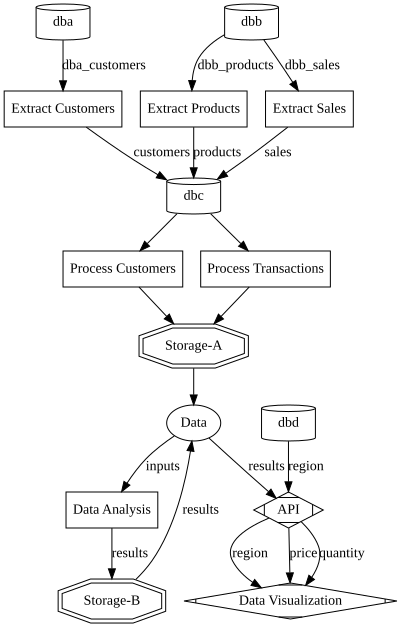

In [9]:
import os
from graphviz import Digraph
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin/'

g = Digraph(filename='c:/test/digraph_example.gv', format='png')
g.graph_attr.update(size='10,10')

#database
g.node('db-a', 'dba', shape='cylinder')
g.node('db-b', 'dbb', shape='cylinder')
g.node('db-c', 'dbc', shape='cylinder')
g.node('db-d', 'dbd', shape='cylinder')

#storage
g.node('st-a', 'Storage-A', shape='doubleoctagon')
g.node('st-b', 'Storage-B', shape='doubleoctagon')

#extract customers
g.node('e-cust', 'Extract Customers', shape='rect')
g.edge('db-a', 'e-cust', label='dba_customers')
g.edge('e-cust', 'db-c', label='customers')

#extract sales
g.node('e-sale', 'Extract Sales', shape='rect')
g.edge('db-b', 'e-sale', label='dbb_sales')
g.edge('e-sale', 'db-c', label='sales')

#extract products
g.node('e-prod', 'Extract Products', shape='rect')
g.edge('db-b', 'e-prod', label='dbb_products')
g.edge('e-prod', 'db-c', label='products')

#process customers
g.node('p-cust', 'Process Customers', shape='rect')
g.edge('db-c', 'p-cust')
g.edge('p-cust', 'st-a')

#process transactions
g.node('p-tran', 'Process Transactions', shape='rect')
g.edge('db-c', 'p-tran')
g.edge('p-tran', 'st-a')

#data package
g.node('d-pkg', 'Data', shape='ellipse')
g.edge('st-a', 'd-pkg')
g.edge('st-b', 'd-pkg', label='results')

#data-api
g.node('d-api', 'API', shape='Mdiamond')
g.edge('d-pkg', 'd-api', label='results')
g.edge('db-d', 'd-api', label='region')

#analysis
g.node('a-data', 'Data Analysis', shape='rect')
g.edge('d-pkg', 'a-data', label='inputs')
g.edge('a-data', 'st-b', label='results')

#visualization
g.node('v-data', 'Data Visualization', shape='Mdiamond')
g.edge('d-api', 'v-data', label='region')
g.edge('d-api', 'v-data', label='price')
g.edge('d-api', 'v-data', label='quantity')

g.save()
g.render(view=0, cleanup=1)
g